<a href="https://colab.research.google.com/github/Amoyeola/Final-Project-Computer-Vision-System-Development/blob/main/VLM_InClass_Lab_ITAI1378_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vision-Language Models (VLMs) — In-Class Lab

**Course:** ITAI 1378 · **Duration:** ~75–90 minutes · **Tools:** Google Colab (free GPU)

In this lab you will use two real vision-language models to *see* how images and text
are connected inside a shared embedding space:

1. **CLIP** (OpenAI) — matches images to text. You'll use it for **zero-shot image classification**
   (classifying images into categories the model was *never explicitly trained on*).
2. **BLIP** (Salesforce) — a **generative** VLM. You'll use it to **caption images** and answer
   **questions about images** (VQA).

### Learning objectives
By the end you will be able to:
- Explain how CLIP turns images and text into comparable **embeddings**.
- Build a **zero-shot classifier** from nothing but class names.
- Show that **prompt wording changes accuracy** (prompt engineering).
- Generate captions and answers for an image you upload yourself.

### How to work
- Cells marked **`# TODO`** are for *you* to complete. Everything else you just **run**.
- Run cells top to bottom (`Shift+Enter`).
- Answer the **Reflection questions** at the bottom in the final markdown cell and submit the notebook.

---
### ⚙️ Before you start — turn on the GPU
`Runtime → Change runtime type → Hardware accelerator → T4 GPU → Save`.
Everything runs on CPU too, just slower.


## Part 0 — Setup

Install the libraries and import what we need. This first cell downloads a few packages, so
give it ~30 seconds. `torch` and `PIL` are already installed on Colab.

In [1]:
!pip install -q transformers datasets

In [2]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on:", device)

def show(img, title=""):
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()

Running on: cuda


## Part 1 — Load CLIP

**How CLIP works (the 30-second version):** CLIP has *two* encoders — one for images, one for text.
It was trained on 400M image–caption pairs so that a matching image and caption land at nearly the
**same point** in a shared vector space, while mismatched pairs land far apart. To use it we encode an
image and some candidate texts, then measure **similarity** (a dot product). The closest text "wins".

We use `clip-vit-base-patch32` — the small, fast version (~600 MB download).

In [3]:
from transformers import CLIPProcessor, CLIPModel

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
print("CLIP loaded.")

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP loaded.


## Part 2 — Image ↔ text similarity  *(your first TODO)*

Let's build intuition on a single image. We grab one picture from the dataset and ask CLIP:
*"Which of these captions best matches this image?"*

The processor turns text + image into tensors; the model returns `logits_per_image`, a
similarity score for each caption. Apply `softmax` to read them as probabilities.

**TODO:** Fill in the two missing lines so `probs` holds one probability per caption.

README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  120MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.9MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

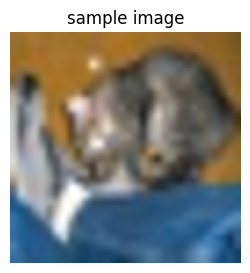

 70.3%  a photo of a cat
  0.8%  a photo of a truck
  0.8%  a photo of an airplane in the sky
 28.1%  a photo of a dog


In [4]:
# We'll reuse this sample image throughout Part 2.
from datasets import load_dataset
_peek = load_dataset("uoft-cs/cifar10", split="test[:1]")
sample_image = _peek[0]["img"].resize((160, 160))   # upscale so it's easier to see
show(sample_image, "sample image")

candidate_captions = [
    "a photo of a cat",
    "a photo of a truck",
    "a photo of an airplane in the sky",
    "a photo of a dog",
]

# TODO 1a: build the model inputs. Pass BOTH the text list and the image.
#          Hint: clip_processor(text=..., images=..., return_tensors="pt", padding=True)
inputs = clip_processor(
    text=candidate_captions,
    images=sample_image,
    return_tensors="pt",
    padding=True
) # <-- YOUR CODE HERE
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = clip_model(**inputs)

# logits_per_image has shape [1, num_captions]
logits = outputs.logits_per_image

# TODO 1b: convert logits to probabilities across the captions (dim=1)
probs = logits.softmax(dim=1) # <-- YOUR CODE HERE

for caption, p in zip(candidate_captions, probs[0].tolist()):
    print(f"{p:6.1%}  {caption}")

**Check yourself:** the probabilities should sum to 100% and the highest one should match
what's actually in the picture. Try swapping in your *own* captions above and rerun.

## Part 3 — The dataset: CIFAR-10

**What it is:** CIFAR-10 is a classic benchmark of 60,000 tiny (32×32) colour photos across
**10 everyday categories**: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

**Where it comes from:** we stream it straight from the Hugging Face Hub
(`uoft-cs/cifar10`) — no manual download, no signup. We'll use a random **300-image** slice of the
test split so the lab runs in seconds.

Run the cell to load it and preview a few images with their true labels.

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Loaded 300 images.



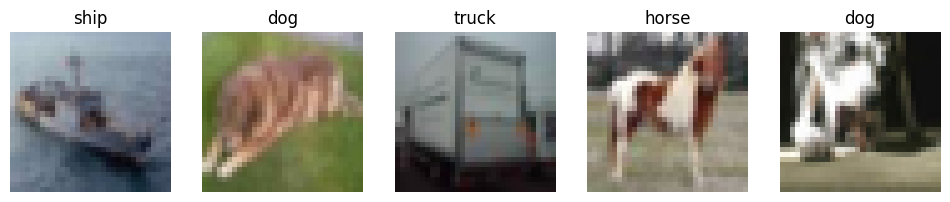

In [5]:
from datasets import load_dataset

N = 300  # sample size — bump to 1000 if you want a sturdier accuracy estimate
full = load_dataset("uoft-cs/cifar10", split="test")
data = full.shuffle(seed=42).select(range(N))

# The image column is called "img" in this dataset (be defensive just in case).
IMG_COL = "img" if "img" in data.column_names else "image"

class_names = data.features["label"].names
print("Classes:", class_names)
print(f"Loaded {len(data)} images.\n")

# Preview 5 images
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for ax, ex in zip(axes, data.select(range(5))):
    ax.imshow(ex[IMG_COL]); ax.axis("off")
    ax.set_title(class_names[ex["label"]])
plt.show()

## Part 4 — Zero-shot classification  *(main TODO)*

Here's the key idea: CLIP has **never been trained on CIFAR-10 labels**. Instead we turn each of the
10 class names into a sentence (a *prompt*), encode all 10 once, then for each image pick the class
whose text embedding is **most similar** to the image embedding. That's zero-shot classification.

### Step 1 — Encode the class prompts once (given)
Encoding the 10 prompts a single time (instead of per image) makes the whole loop fast.

In [7]:
def encode_text(prompt_list):
    text_inputs = clip_processor(
        text=prompt_list,
        return_tensors="pt",
        padding=True
    )
    text_inputs = {k: v.to(device) for k, v in text_inputs.items()}

    with torch.no_grad():
        text_output = clip_model.get_text_features(**text_inputs)

    # Compatibility with old and new Transformers versions
    if hasattr(text_output, "pooler_output"):
        feats = text_output.pooler_output
    else:
        feats = text_output

    return feats / feats.norm(dim=-1, keepdim=True)

text_features = encode_text(prompts)

print("text_features shape:", tuple(text_features.shape))

text_features shape: (10, 512)


### Step 2 — Classify one image  *(TODO)*
Complete `classify()`. Encode the image, normalize it, then compute similarity against
`text_features` and return the index of the best-matching class.

In [9]:
def classify(image, text_feats):
    # Encode the image
    image_inputs = clip_processor(
        images=image,
        return_tensors="pt"
    )
    image_inputs = {
        k: v.to(device)
        for k, v in image_inputs.items()
    }

    with torch.no_grad():
        image_output = clip_model.get_image_features(**image_inputs)

    # Compatibility with the current Transformers version
    if hasattr(image_output, "pooler_output"):
        img_feats = image_output.pooler_output
    else:
        img_feats = image_output

    # Normalize the image embedding
    img_feats = img_feats / img_feats.norm(
        dim=-1,
        keepdim=True
    )

    # Compare the image embedding with all text embeddings
    similarities = (img_feats @ text_feats.T).squeeze(0)

    predicted_index = int(similarities.argmax())

    return predicted_index, similarities

### Step 3 — Measure accuracy over the whole sample  *(TODO)*
Loop over the 300 images, classify each, and count how many predictions match the true label.

In [10]:
def evaluate(dataset, text_feats):
    correct = 0
    for ex in tqdm(dataset, desc="classifying"):
        pred, _ = classify(ex[IMG_COL], text_feats)
        # TODO 3: increment `correct` when the prediction matches ex["label"]
        if pred == ex["label"]:
             correct += 1 # <-- YOUR CODE HERE (replace this line)
    return correct / len(dataset)

accuracy = evaluate(data, text_features)
print(f"\nZero-shot accuracy: {accuracy:.1%}")

classifying:   0%|          | 0/300 [00:00<?, ?it/s]


Zero-shot accuracy: 90.3%


> **What to expect:** with the `"a photo of a {}"` prompt you should see roughly **85–90%**.
> Not bad for a model that never saw a single CIFAR training label!

### Step 4 — Look at the mistakes (given)
Understanding *where* it fails is more useful than the single accuracy number.

29 misclassified out of 300


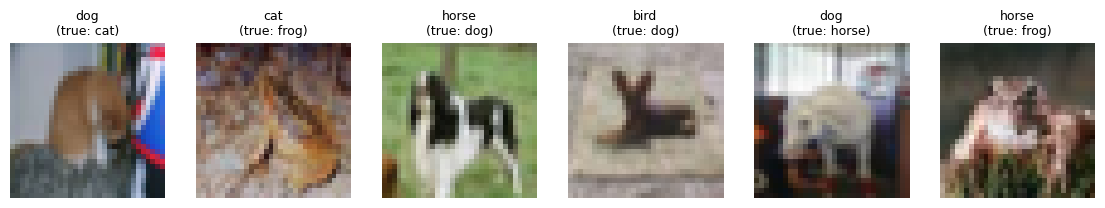

In [11]:
wrong = []
for ex in data:
    pred, _ = classify(ex[IMG_COL], text_features)
    if pred != ex["label"]:
        wrong.append((ex, pred))

print(f"{len(wrong)} misclassified out of {len(data)}")

# Show up to 6 mistakes: title = "pred / true"
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for ax, (ex, pred) in zip(axes, wrong[:6]):
    ax.imshow(ex[IMG_COL]); ax.axis("off")
    ax.set_title(f"{class_names[pred]}\n(true: {class_names[ex['label']]})", fontsize=9)
plt.show()

## Part 5 — Prompt engineering  *(TODO)*

The *only* text CLIP sees is your prompt, so wording matters. Compare a few templates and see how
accuracy shifts. **TODO:** add at least one template of your own to the list, run the cell, and
**write down the numbers** for the Reflection section.

In [12]:
templates = [
    "{}",                       # bare class name
    "a photo of a {}",          # the classic CLIP prompt
    "a blurry low-resolution photo of a {}",
     "a small image of a {}",
    "a low-resolution picture of a {}",

]# TODO 4: add one or two of your OWN templates below, e.g. "a picture of a {} on a plain background"


results = {}
for tmpl in templates:
    feats = encode_text([tmpl.format(c) for c in class_names])
    acc = evaluate(data, feats)
    results[tmpl] = acc

print("\n=== Prompt comparison ===")
for tmpl, acc in sorted(results.items(), key=lambda x: -x[1]):
    print(f"{acc:6.1%}   \"{tmpl}\"")

classifying:   0%|          | 0/300 [00:00<?, ?it/s]

classifying:   0%|          | 0/300 [00:00<?, ?it/s]

classifying:   0%|          | 0/300 [00:00<?, ?it/s]

classifying:   0%|          | 0/300 [00:00<?, ?it/s]

classifying:   0%|          | 0/300 [00:00<?, ?it/s]


=== Prompt comparison ===
 91.0%   "a low-resolution picture of a {}"
 90.7%   "a blurry low-resolution photo of a {}"
 90.3%   "a photo of a {}"
 89.0%   "a small image of a {}"
 87.7%   "{}"


## Part 6 — Image captioning with BLIP (a generative VLM)

CLIP *matches* text to images. BLIP can **write** text about an image. Let's load BLIP and caption
an image **you** choose.

First load the model (~1 GB download).

In [13]:
from transformers import BlipProcessor, BlipForConditionalGeneration

blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base").to(device)

def caption(image):
    inputs = blip_processor(image, return_tensors="pt").to(device)
    with torch.no_grad():
        out = blip_model.generate(**inputs, max_new_tokens=30)
    return blip_processor.decode(out[0], skip_special_tokens=True)

print("BLIP captioning model loaded.")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

BLIP captioning model loaded.


### Upload your own image
Run the cell below and pick any photo from your computer. *(Not on Colab? Skip the upload and set
`my_image = Image.open("path/to/your.jpg").convert("RGB")` instead.)*

Saving IMG_7113.jpg to IMG_7113.jpg


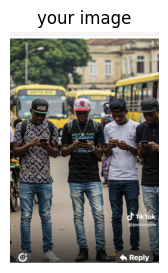

BLIP caption: a group of men standing on a street


In [14]:
try:
    from google.colab import files
    uploaded = files.upload()
    fname = next(iter(uploaded))
    my_image = Image.open(fname).convert("RGB")
except Exception as e:
    print("Colab upload unavailable — set my_image manually. Details:", e)
    # my_image = Image.open("your_image.jpg").convert("RGB")

show(my_image, "your image")
print("BLIP caption:", caption(my_image))

Try it on a couple of the CIFAR images too — notice how the tiny 32×32 resolution limits how
much detail BLIP can describe. That's a real VLM constraint: **input resolution matters.**

In [15]:
for ex in data.select(range(3)):
    print(f"[{class_names[ex['label']]:>10}] -> {caption(ex[IMG_COL])}")

[      ship] -> a boat floating in the water with fog
[       dog] -> adopt a dog in your area
[     truck] -> a truck with a trailer in the background


## Part 7 — (Optional / bonus) Visual Question Answering

If you have time, load BLIP's VQA model and *ask questions* about your uploaded image.
This is a separate ~1.5 GB download, so skip it if the class is running short on time.

In [17]:
from transformers import BlipForQuestionAnswering

vqa_processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
vqa_model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base").to(device)

def ask(image, question):
    inputs = vqa_processor(image, question, return_tensors="pt").to(device)
    with torch.no_grad():
        out = vqa_model.generate(**inputs, max_new_tokens=20)
    return vqa_processor.decode(out[0], skip_special_tokens=True)

# TODO 5: write at least 3 questions about YOUR image (colors, counts, objects, setting...)
questions = [
    "what is in the image?",
    "how many men are in the foreground?",
    "what are the men holding?",
    "what color are the buses?",
    "are the men indoors or outdoors?",
    "what are the men doing?"

    # add more here
]

for q in questions:
    print(f"Q: {q}\nA: {ask(my_image, q)}\n")

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

Q: what is in the image?
A: people

Q: how many men are in the foreground?
A: 5

Q: what are the men holding?
A: phones

Q: what color are the buses?
A: yellow

Q: are the men indoors or outdoors?
A: outdoors

Q: what are the men doing?
A: texting



In [18]:
from collections import Counter

confusion_counts = Counter(
    (class_names[ex["label"]], class_names[pred])
    for ex, pred in wrong
)

print("Most common confusion pairs:")

for (true_class, predicted_class), count in confusion_counts.most_common(10):
    print(
        "True:", true_class,
        "| Predicted:", predicted_class,
        "| Count:", count
    )

Most common confusion pairs:
True: frog | Predicted: cat | Count: 5
True: truck | Predicted: automobile | Count: 4
True: dog | Predicted: bird | Count: 2
True: deer | Predicted: dog | Count: 2
True: frog | Predicted: bird | Count: 2
True: cat | Predicted: dog | Count: 1
True: dog | Predicted: horse | Count: 1
True: horse | Predicted: dog | Count: 1
True: frog | Predicted: horse | Count: 1
True: deer | Predicted: ship | Count: 1


## Reflection — answer these and submit the notebook

Double-click this cell to edit it and type your answers inline. Base every answer on **your own runs**.

1. **Accuracy:** What zero-shot accuracy did you get with `"a photo of a {}"`? Looking at the
   misclassified examples in Part 4, which two classes did CLIP confuse most, and why do you think so?

   - I obtained a zero-shot accuracy of 90.3% using the prompt “a photo of a {}.” CLIP misclassified 29 out of the 300 images. The two most common confusion pairs were frog predicted as cat, which occurred five times, and truck predicted as automobile, which occurred four times. I think the frog and cat images were confused because CIFAR-10 images are only 32 × 32 pixels, making small animals difficult to distinguish when their shapes and backgrounds appear similar. Trucks and automobiles also share features such as wheels, roads, and similar vehicle shapes, so the low image resolution made those categories harder to separate.

2. **Prompt engineering:** List each template you tried and its accuracy. Which was best, which was
   worst, and what does that tell you about how CLIP "reads" prompts? (Give exact numbers.)

   - I tested five prompt templates. “A low-resolution picture of a {}” achieved 91.0%, “a blurry low-resolution photo of a {}” achieved 90.7%, “a photo of a {}” achieved 90.3%, “a small image of a {}” achieved 89.0%, and the bare class name “{}” achieved 87.7%. The low-resolution picture prompt performed best, while the bare class name performed worst. This suggests that CLIP uses the surrounding words as context. Describing the images as low-resolution matched the visual characteristics of CIFAR-10 better than providing only the class names.

3. **Captioning:** Was BLIP's caption of your uploaded image accurate? Name one thing it got right
   and one it got wrong or missed.

   - BLIP’s caption, “a group of men standing on a street,” was generally accurate. It correctly recognized the group of men and the outdoor street setting. However, it missed the main activity: the men were holding and looking at mobile phones. It also did not mention the yellow buses in the background.

4. **VQA (if you did Part 7):** Give one question BLIP answered correctly and one it got wrong.
   Why do you think it failed on that one?

   - BLIP correctly answered the question “What are the men holding?” with “phones.” It also correctly identified the yellow buses, the outdoor setting, and that the men were texting. However, it answered “5” when asked how many men were in the foreground, although four men were clearly visible in the foreground. It may have counted one of the partially visible people in the background because the image contains several overlapping people.

5. **Concept check:** In 2–3 sentences, explain how zero-shot classification works. You **must** use
   the words **embedding** and **similarity**.

   - Zero-shot classification works by converting an image and the possible class descriptions into an embedding within the same feature space. The model calculates the similarity between the image embedding and each text embedding, then selects the class description with the highest similarity.

---
### Submission
`File → Download → Download .ipynb` (make sure your outputs are visible) and upload it to the course portal.
